# Streamlit Dummy UI Test Notebook

This notebook helps you test the same dummy prediction logic used in the Streamlit app and then run the app locally.

In [1]:
import random
import pandas as pd

def hardcoded_prediction(selected_profile: str):
    profiles = {
        "High risk": {
            "vulnerability_score": 0.91,
            "is_vulnerable": True,
            "top_cwe": "CWE-089: SQL Injection",
            "severity": "High",
            "confidence": 0.88,
            "line_risk": [0.22, 0.74, 0.95, 0.31, 0.11],
        },
        "Medium risk": {
            "vulnerability_score": 0.57,
            "is_vulnerable": True,
            "top_cwe": "CWE-078: OS Command Injection",
            "severity": "Medium",
            "confidence": 0.71,
            "line_risk": [0.17, 0.48, 0.68, 0.42, 0.23],
        },
        "Low risk": {
            "vulnerability_score": 0.14,
            "is_vulnerable": False,
            "top_cwe": "None detected",
            "severity": "Low",
            "confidence": 0.93,
            "line_risk": [0.05, 0.07, 0.11, 0.08, 0.04],
        },
    }

    result = dict(profiles[selected_profile])
    jitter = random.uniform(-0.03, 0.03)
    result["vulnerability_score"] = round(min(max(result["vulnerability_score"] + jitter, 0.0), 1.0), 3)
    result["confidence"] = round(min(max(result["confidence"] + jitter, 0.0), 1.0), 3)
    return result

In [2]:
random.seed(42)
profiles = ["High risk", "Medium risk", "Low risk"]
rows = []
for p in profiles:
    pred = hardcoded_prediction(p)
    rows.append({
        "profile": p,
        "vulnerability_score": pred["vulnerability_score"],
        "is_vulnerable": pred["is_vulnerable"],
        "severity": pred["severity"],
        "top_cwe": pred["top_cwe"],
        "confidence": pred["confidence"],
    })

df = pd.DataFrame(rows)
df

,profile,vulnerability_score,is_vulnerable,severity,top_cwe,confidence
0,High risk,0.918,True,High,CWE-089: SQL Injection,0.888
1,Medium risk,0.542,True,Medium,CWE-078: OS Command Injection,0.682
2,Low risk,0.127,False,Low,None detected,0.917


<Axes: title={'center': 'Dummy line-level risk (High risk profile)'}, xlabel='line'>

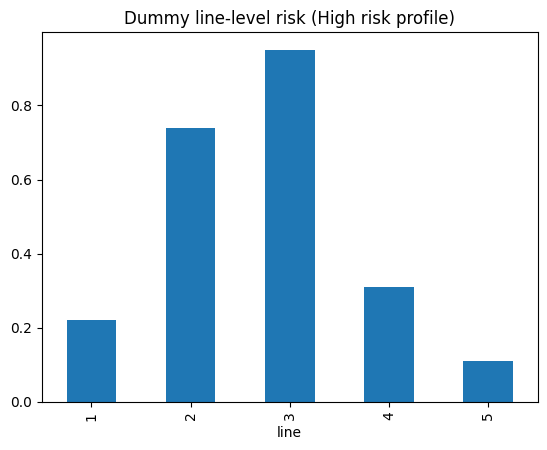

In [3]:
sample = hardcoded_prediction("High risk")
line_df = pd.DataFrame({"line": list(range(1, len(sample["line_risk"]) + 1)), "risk": sample["line_risk"]})
line_df.set_index("line")["risk"].plot(kind="bar", title="Dummy line-level risk (High risk profile)")

## Run Streamlit App Locally
From the project root, run:

`streamlit run app_dummy.py`

Then verify:
- Code input area accepts pasted code
- Sidebar profile changes prediction output
- Button triggers metrics and chart updates
- Layout remains clear on different window sizes